# 01 — Workforce Profiling

Análise exploratória completa da workforce — a "fotografia" da empresa.

Este notebook mapeia a composição do quadro de funcionários, identificando padrões demográficos, estrutura hierárquica, distribuição salarial e satisfação organizacional. Os insights aqui servem de baseline para as análises de turnover e engajamento dos notebooks seguintes.

**Fonte:** `master_dataset.csv` gerado pelo notebook 00.

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Visual Theme ──────────────────────────────────────────────
plt.style.use('dark_background')

COLORS = {
    'primary': '#6366F1',
    'secondary': '#8B5CF6',
    'accent': '#EC4899',
    'success': '#10B981',
    'warning': '#F59E0B',
    'danger': '#EF4444',
    'info': '#06B6D4',
    'text': '#E2E8F0',
    'muted': '#94A3B8',
    'bg': '#0F172A',
    'card': '#1E293B',
    'grid': '#334155'
}

PALETTE_SEQ = ['#6366F1', '#8B5CF6', '#A78BFA', '#C4B5FD', '#DDD6FE']
PALETTE_DIV = ['#EF4444', '#F59E0B', '#10B981', '#06B6D4', '#6366F1']
PALETTE_CAT = ['#6366F1', '#EC4899', '#10B981', '#F59E0B', '#06B6D4', '#8B5CF6', '#EF4444', '#14B8A6', '#F97316']

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],
    'axes.facecolor': COLORS['card'],
    'axes.edgecolor': COLORS['grid'],
    'axes.labelcolor': COLORS['text'],
    'text.color': COLORS['text'],
    'xtick.color': COLORS['muted'],
    'ytick.color': COLORS['muted'],
    'grid.color': COLORS['grid'],
    'grid.alpha': 0.3,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.titlesize': 18,
    'figure.titleweight': 'bold',
})

def format_ax(ax, title='', xlabel='', ylabel='', grid_axis='y'):
    """Apply consistent formatting to axes."""
    ax.set_title(title, pad=15, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if grid_axis:
        ax.grid(axis=grid_axis, alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

print('Libraries loaded. Visual theme configured.')

Libraries loaded. Visual theme configured.


In [2]:
df = pd.read_csv('../data/processed/master_dataset.csv')
print(f'Dataset: {df.shape[0]:,} employees × {df.shape[1]} features')

Dataset: 4,410 employees × 51 features


---
## 2. Executive KPI Overview

Key workforce indicators at a glance — the numbers every executive sees first.

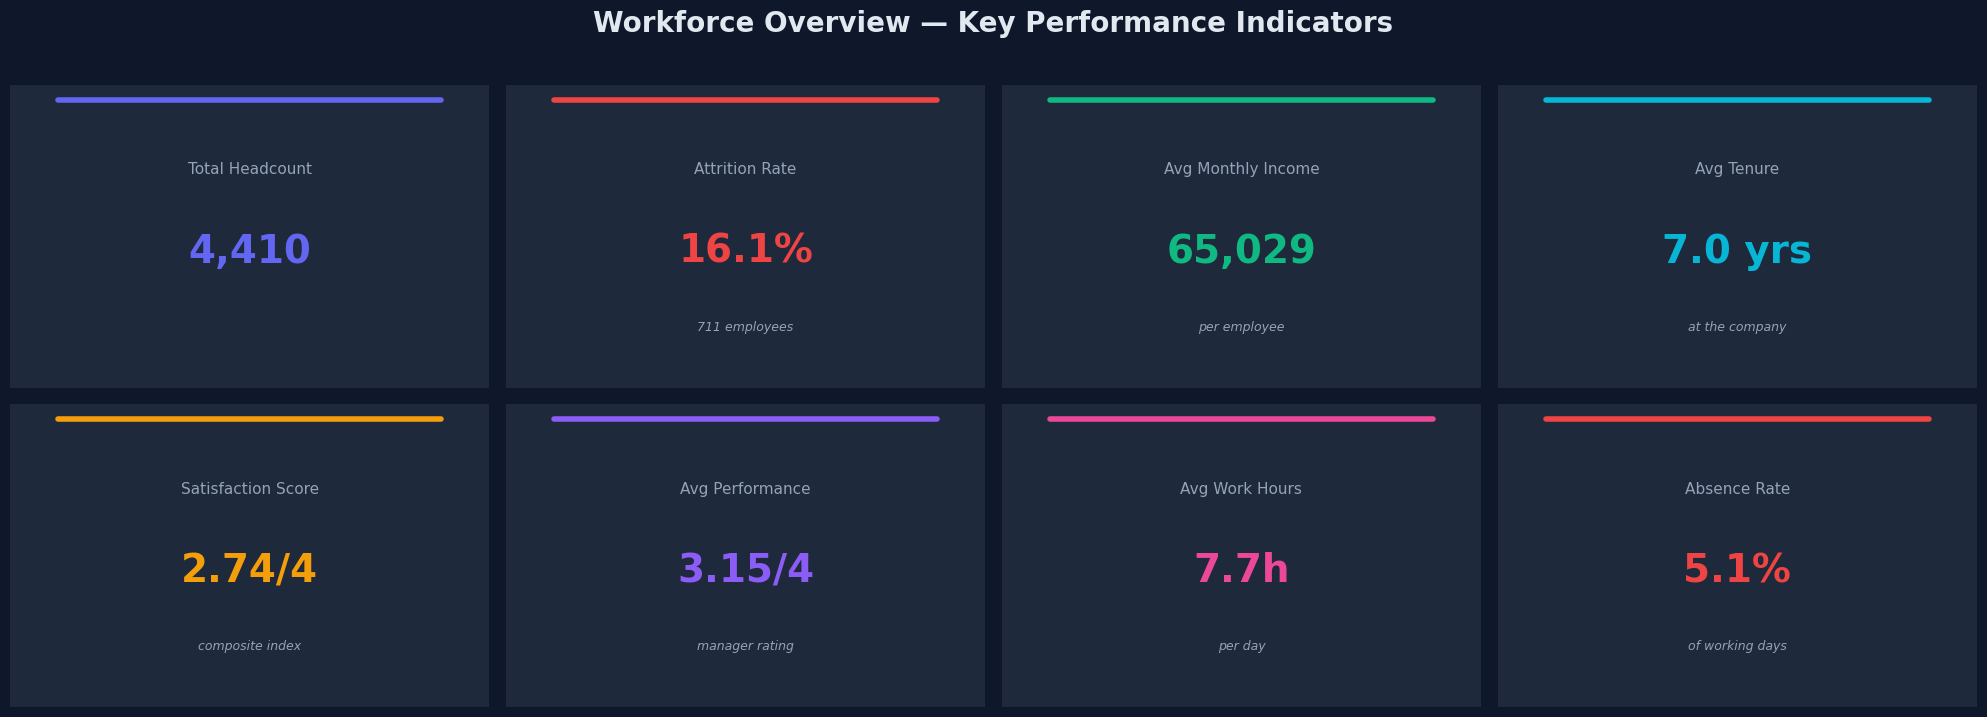

In [3]:
# Calculate KPIs
total_headcount = len(df)
active = df[df['Attrition'] == 'No']
attrited = df[df['Attrition'] == 'Yes']
attrition_rate = len(attrited) / total_headcount * 100
avg_salary = df['MonthlyIncome'].mean()
avg_tenure = df['YearsAtCompany'].mean()
avg_satisfaction = df['SatisfactionScore'].mean()
avg_performance = df['PerformanceRating'].mean()
avg_work_hours = df['AvgDailyWorkHours'].mean()
absence_rate = df['AbsenceRate'].mean()

# KPI Cards visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 7))
fig.suptitle('Workforce Overview — Key Performance Indicators', fontsize=20, fontweight='bold', y=1.02)

kpis = [
    ('Total Headcount', f'{total_headcount:,}', '', COLORS['primary']),
    ('Attrition Rate', f'{attrition_rate:.1f}%', f'{len(attrited)} employees', COLORS['danger']),
    ('Avg Monthly Income', f'{avg_salary:,.0f}', 'per employee', COLORS['success']),
    ('Avg Tenure', f'{avg_tenure:.1f} yrs', 'at the company', COLORS['info']),
    ('Satisfaction Score', f'{avg_satisfaction:.2f}/4', 'composite index', COLORS['warning']),
    ('Avg Performance', f'{avg_performance:.2f}/4', 'manager rating', COLORS['secondary']),
    ('Avg Work Hours', f'{avg_work_hours:.1f}h', 'per day', COLORS['accent']),
    ('Absence Rate', f'{absence_rate:.1f}%', 'of working days', COLORS['danger'] if absence_rate > 5 else COLORS['success']),
]

for ax, (title, value, subtitle, color) in zip(axes.flat, kpis):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_facecolor(COLORS['card'])
    
    # Accent bar at top
    ax.axhline(y=0.95, xmin=0.1, xmax=0.9, color=color, linewidth=4, solid_capstyle='round')
    
    ax.text(0.5, 0.72, title, fontsize=11, ha='center', va='center', color=COLORS['muted'], fontweight='medium')
    ax.text(0.5, 0.45, value, fontsize=28, ha='center', va='center', color=color, fontweight='bold')
    ax.text(0.5, 0.2, subtitle, fontsize=9, ha='center', va='center', color=COLORS['muted'], style='italic')
    
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig('../reports/kpi_overview.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

---
## 3. Demographic Profile

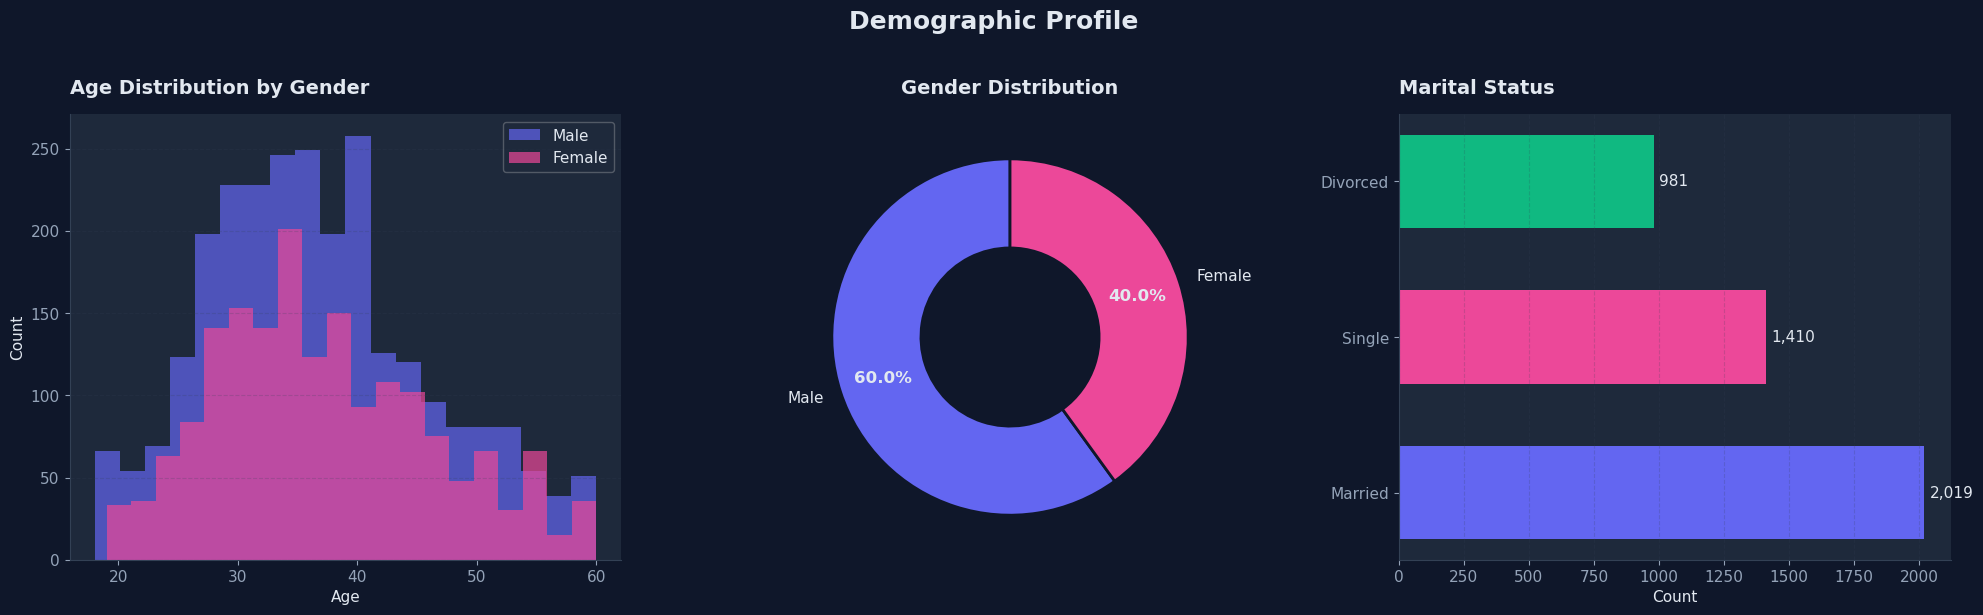

In [4]:
# Age distribution with gender breakdown
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Demographic Profile', fontsize=18, fontweight='bold', y=1.02)

# ── Age Distribution ──
ax = axes[0]
for i, gender in enumerate(['Male', 'Female']):
    data = df[df['Gender'] == gender]['Age']
    ax.hist(data, bins=20, alpha=0.7, color=PALETTE_CAT[i], label=gender, edgecolor='none')
format_ax(ax, 'Age Distribution by Gender', 'Age', 'Count')
ax.legend(framealpha=0.3)

# ── Gender Split ──
ax = axes[1]
gender_counts = df['Gender'].value_counts()
wedges, texts, autotexts = ax.pie(
    gender_counts, labels=gender_counts.index,
    autopct='%1.1f%%', colors=[COLORS['primary'], COLORS['accent']],
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor=COLORS['bg'], linewidth=2)
)
for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight('bold')
ax.set_title('Gender Distribution', fontsize=14, fontweight='bold', pad=15)

# ── Marital Status ──
ax = axes[2]
ms_counts = df['MaritalStatus'].value_counts()
bars = ax.barh(ms_counts.index, ms_counts.values, color=PALETTE_CAT[:3], edgecolor='none', height=0.6)
for bar, val in zip(bars, ms_counts.values):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=11, color=COLORS['text'])
format_ax(ax, 'Marital Status', 'Count', '', grid_axis='x')

plt.tight_layout()
plt.savefig('../reports/demographic_profile.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

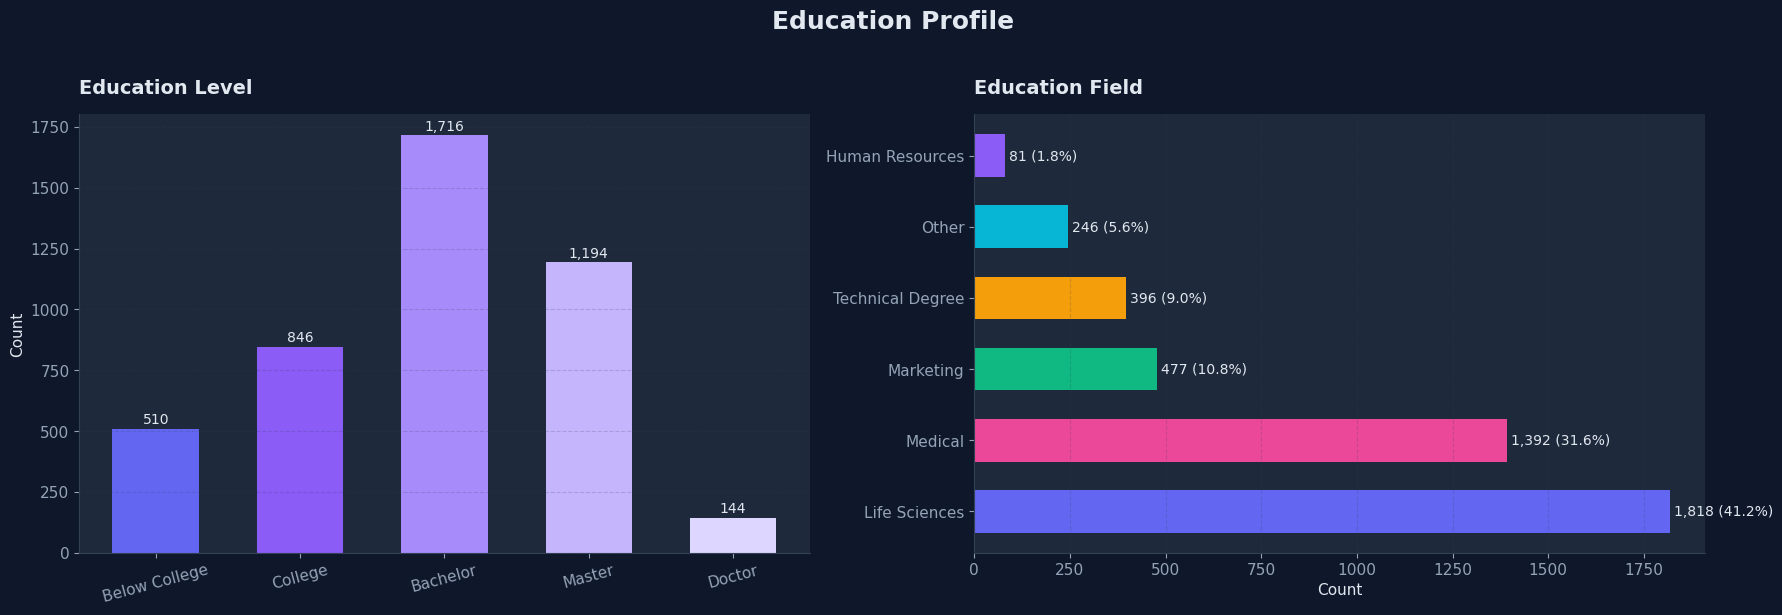

In [5]:
# Education breakdown
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Education Profile', fontsize=18, fontweight='bold', y=1.02)

# ── Education Level ──
ax = axes[0]
edu_map = {1: 'Below College', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor'}
df['EducationLabel'] = df['Education'].map(edu_map)
edu_order = ['Below College', 'College', 'Bachelor', 'Master', 'Doctor']
edu_counts = df['EducationLabel'].value_counts().reindex(edu_order)
bars = ax.bar(edu_counts.index, edu_counts.values, color=PALETTE_SEQ, edgecolor='none', width=0.6)
for bar, val in zip(bars, edu_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 20, f'{val:,}', ha='center', fontsize=10, color=COLORS['text'])
format_ax(ax, 'Education Level', '', 'Count')
ax.tick_params(axis='x', rotation=15)

# ── Education Field ──
ax = axes[1]
field_counts = df['EducationField'].value_counts()
bars = ax.barh(field_counts.index, field_counts.values, color=PALETTE_CAT[:len(field_counts)], edgecolor='none', height=0.6)
for bar, val in zip(bars, field_counts.values):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, f'{val:,} ({val/len(df)*100:.1f}%)', 
            va='center', fontsize=10, color=COLORS['text'])
format_ax(ax, 'Education Field', 'Count', '', grid_axis='x')

plt.tight_layout()
plt.savefig('../reports/education_profile.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

---
## 4. Organizational Structure

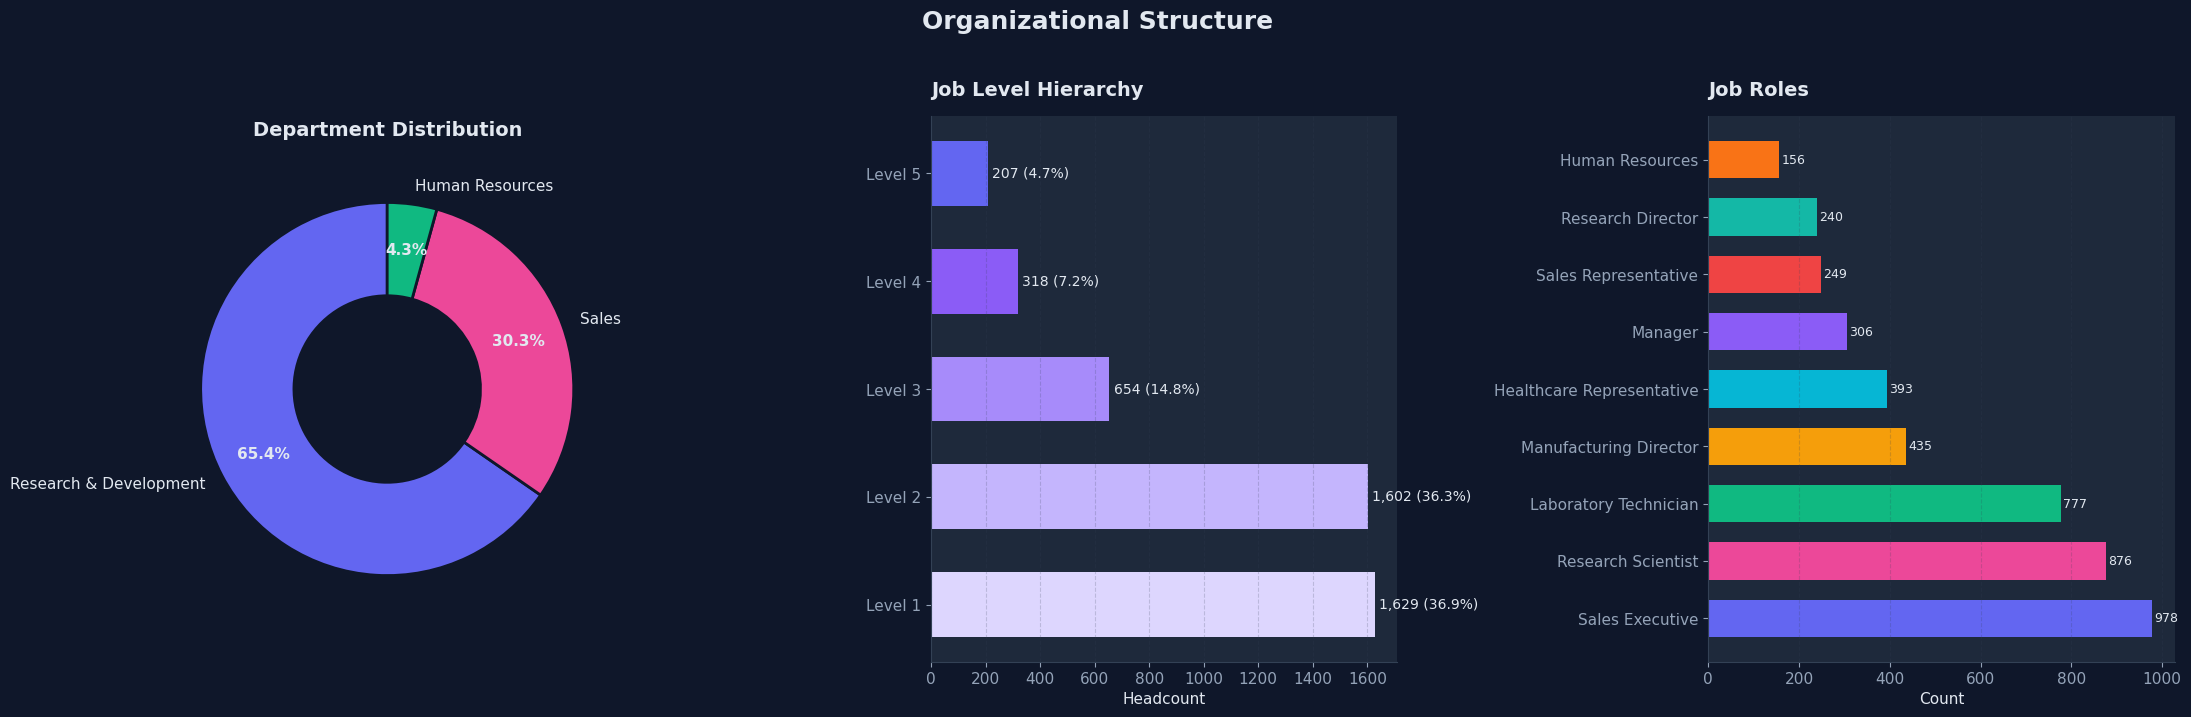

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Organizational Structure', fontsize=18, fontweight='bold', y=1.02)

# ── Department Distribution ──
ax = axes[0]
dept_counts = df['Department'].value_counts()
wedges, texts, autotexts = ax.pie(
    dept_counts, labels=dept_counts.index,
    autopct='%1.1f%%', colors=PALETTE_CAT[:3],
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor=COLORS['bg'], linewidth=2)
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
ax.set_title('Department Distribution', fontsize=14, fontweight='bold', pad=15)

# ── Job Level Pyramid ──
ax = axes[1]
level_counts = df['JobLevel'].value_counts().sort_index()
level_labels = [f'Level {i}' for i in level_counts.index]
bars = ax.barh(level_labels, level_counts.values, color=PALETTE_SEQ[::-1], edgecolor='none', height=0.6)
for bar, val in zip(bars, level_counts.values):
    pct = val / len(df) * 100
    ax.text(val + 15, bar.get_y() + bar.get_height()/2, f'{val:,} ({pct:.1f}%)', 
            va='center', fontsize=10, color=COLORS['text'])
format_ax(ax, 'Job Level Hierarchy', 'Headcount', '', grid_axis='x')

# ── Job Role Distribution ──
ax = axes[2]
role_counts = df['JobRole'].value_counts()
bars = ax.barh(role_counts.index, role_counts.values, color=PALETTE_CAT[:len(role_counts)], 
               edgecolor='none', height=0.65)
for bar, val in zip(bars, role_counts.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, f'{val:,}', 
            va='center', fontsize=9, color=COLORS['text'])
format_ax(ax, 'Job Roles', 'Count', '', grid_axis='x')

plt.tight_layout()
plt.savefig('../reports/org_structure.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

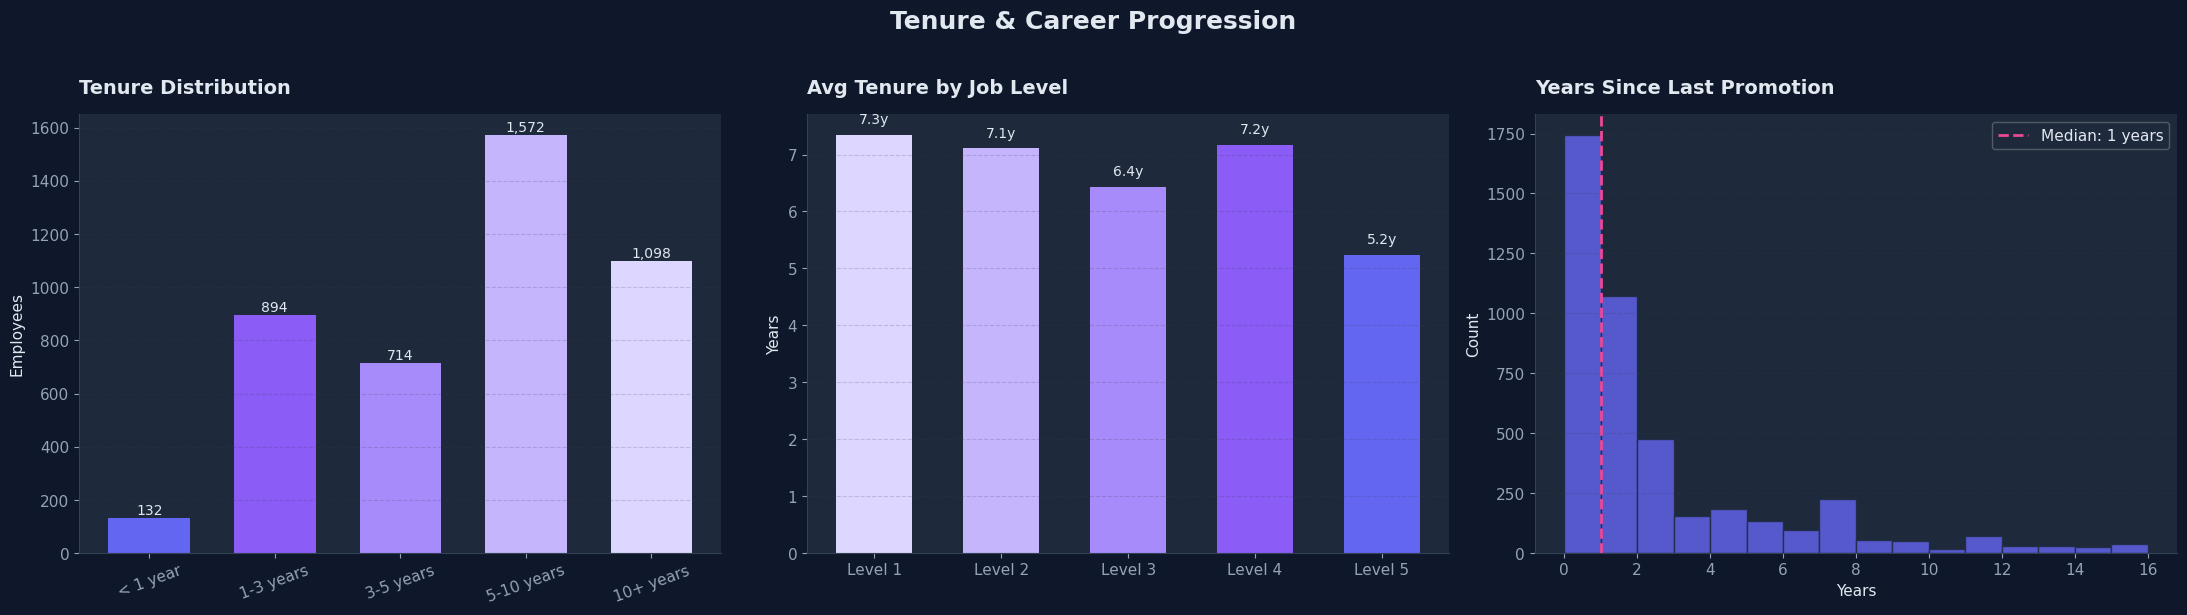

In [7]:
# Tenure distribution and career progression
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Tenure & Career Progression', fontsize=18, fontweight='bold', y=1.02)

# ── Tenure Distribution ──
ax = axes[0]
tenure_counts = df['TenureGroup'].value_counts().reindex(['< 1 year', '1-3 years', '3-5 years', '5-10 years', '10+ years'])
bars = ax.bar(tenure_counts.index, tenure_counts.values, color=PALETTE_SEQ, edgecolor='none', width=0.65)
for bar, val in zip(bars, tenure_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 15, f'{val:,}', ha='center', fontsize=10, color=COLORS['text'])
format_ax(ax, 'Tenure Distribution', '', 'Employees')
ax.tick_params(axis='x', rotation=20)

# ── Avg Tenure by Job Level ──
ax = axes[1]
avg_tenure_level = df.groupby('JobLevel')['YearsAtCompany'].mean().sort_index()
bars = ax.bar([f'Level {i}' for i in avg_tenure_level.index], avg_tenure_level.values, 
              color=PALETTE_SEQ[::-1], edgecolor='none', width=0.6)
for bar, val in zip(bars, avg_tenure_level.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2, f'{val:.1f}y', ha='center', fontsize=10, color=COLORS['text'])
format_ax(ax, 'Avg Tenure by Job Level', '', 'Years')

# ── Years Since Last Promotion ──
ax = axes[2]
ax.hist(df['YearsSinceLastPromotion'], bins=range(0, 17), color=COLORS['primary'], 
        edgecolor=COLORS['card'], alpha=0.8)
ax.axvline(df['YearsSinceLastPromotion'].median(), color=COLORS['accent'], linestyle='--', linewidth=2,
           label=f'Median: {df["YearsSinceLastPromotion"].median():.0f} years')
format_ax(ax, 'Years Since Last Promotion', 'Years', 'Count')
ax.legend(framealpha=0.3)

plt.tight_layout()
plt.savefig('../reports/tenure_career.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

---
## 5. Compensation Analysis

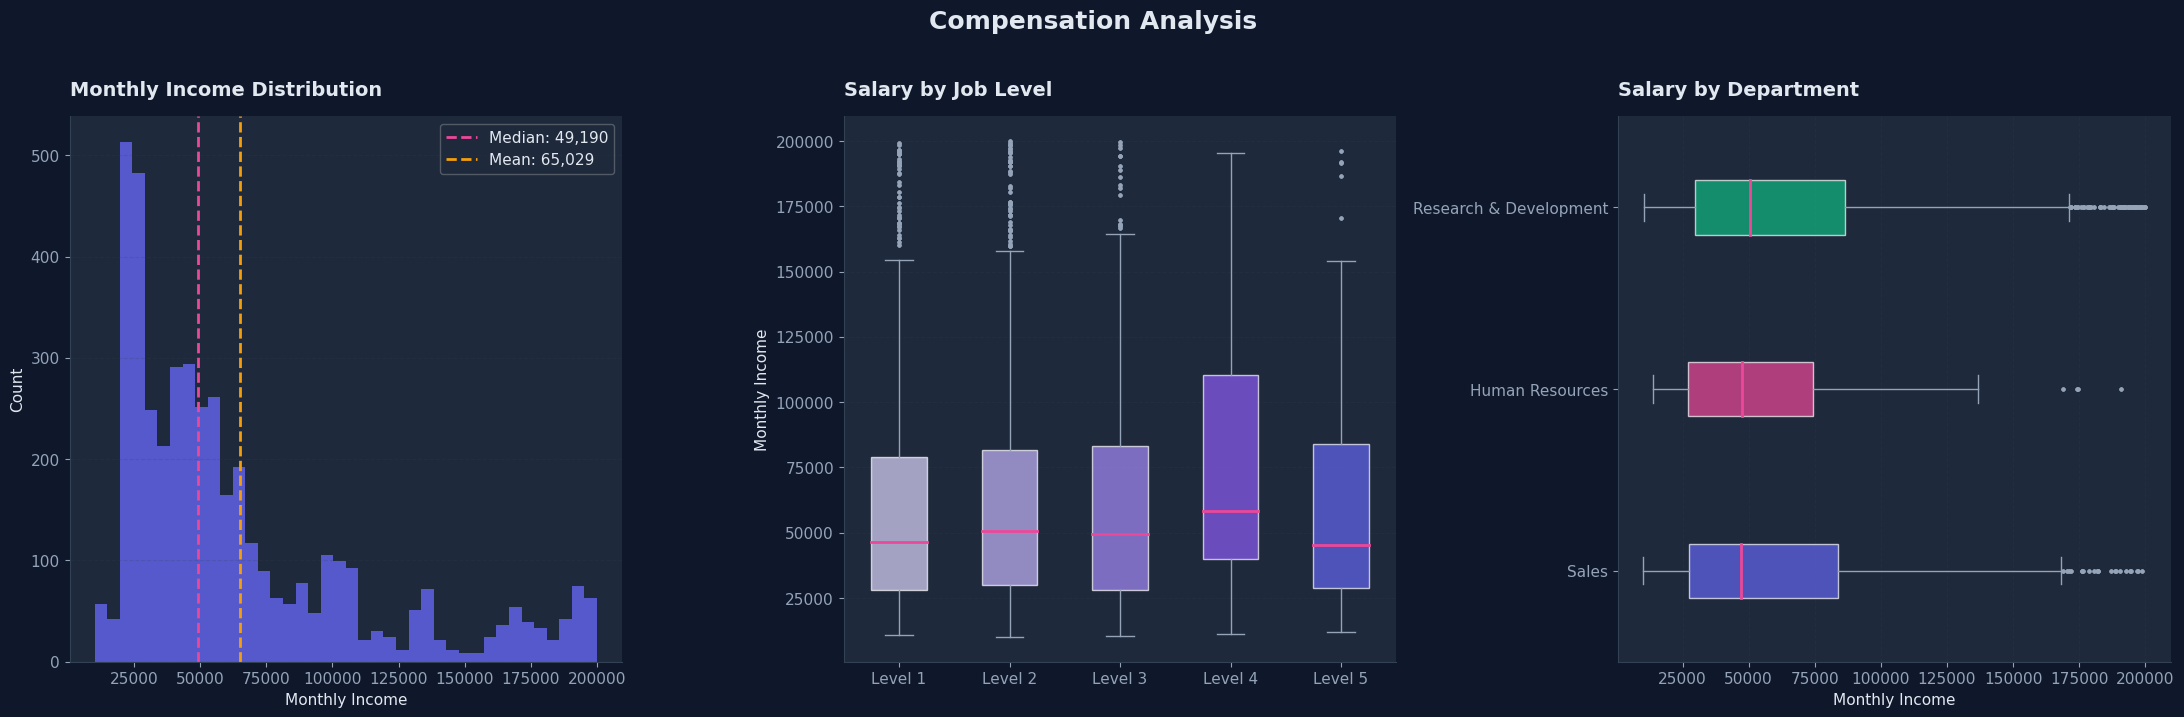

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Compensation Analysis', fontsize=18, fontweight='bold', y=1.02)

# ── Salary Distribution ──
ax = axes[0]
ax.hist(df['MonthlyIncome'], bins=40, color=COLORS['primary'], edgecolor='none', alpha=0.8)
ax.axvline(df['MonthlyIncome'].median(), color=COLORS['accent'], linestyle='--', linewidth=2,
           label=f'Median: {df["MonthlyIncome"].median():,.0f}')
ax.axvline(df['MonthlyIncome'].mean(), color=COLORS['warning'], linestyle='--', linewidth=2,
           label=f'Mean: {df["MonthlyIncome"].mean():,.0f}')
format_ax(ax, 'Monthly Income Distribution', 'Monthly Income', 'Count')
ax.legend(framealpha=0.3)

# ── Salary by Job Level (Box Plot) ──
ax = axes[1]
level_order = sorted(df['JobLevel'].unique())
bp = ax.boxplot(
    [df[df['JobLevel'] == level]['MonthlyIncome'] for level in level_order],
    labels=[f'Level {l}' for l in level_order],
    patch_artist=True,
    boxprops=dict(facecolor=COLORS['primary'], alpha=0.6),
    medianprops=dict(color=COLORS['accent'], linewidth=2),
    whiskerprops=dict(color=COLORS['muted']),
    capprops=dict(color=COLORS['muted']),
    flierprops=dict(markerfacecolor=COLORS['muted'], markeredgecolor='none', markersize=3)
)
for patch, color in zip(bp['boxes'], PALETTE_SEQ[::-1]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
format_ax(ax, 'Salary by Job Level', '', 'Monthly Income')

# ── Salary by Department ──
ax = axes[2]
dept_order = df.groupby('Department')['MonthlyIncome'].median().sort_values(ascending=True).index
bp = ax.boxplot(
    [df[df['Department'] == dept]['MonthlyIncome'] for dept in dept_order],
    labels=dept_order,
    patch_artist=True,
    vert=False,
    boxprops=dict(alpha=0.6),
    medianprops=dict(color=COLORS['accent'], linewidth=2),
    whiskerprops=dict(color=COLORS['muted']),
    capprops=dict(color=COLORS['muted']),
    flierprops=dict(markerfacecolor=COLORS['muted'], markeredgecolor='none', markersize=3)
)
for patch, color in zip(bp['boxes'], PALETTE_CAT[:3]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
format_ax(ax, 'Salary by Department', 'Monthly Income', '', grid_axis='x')

plt.tight_layout()
plt.savefig('../reports/compensation_analysis.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

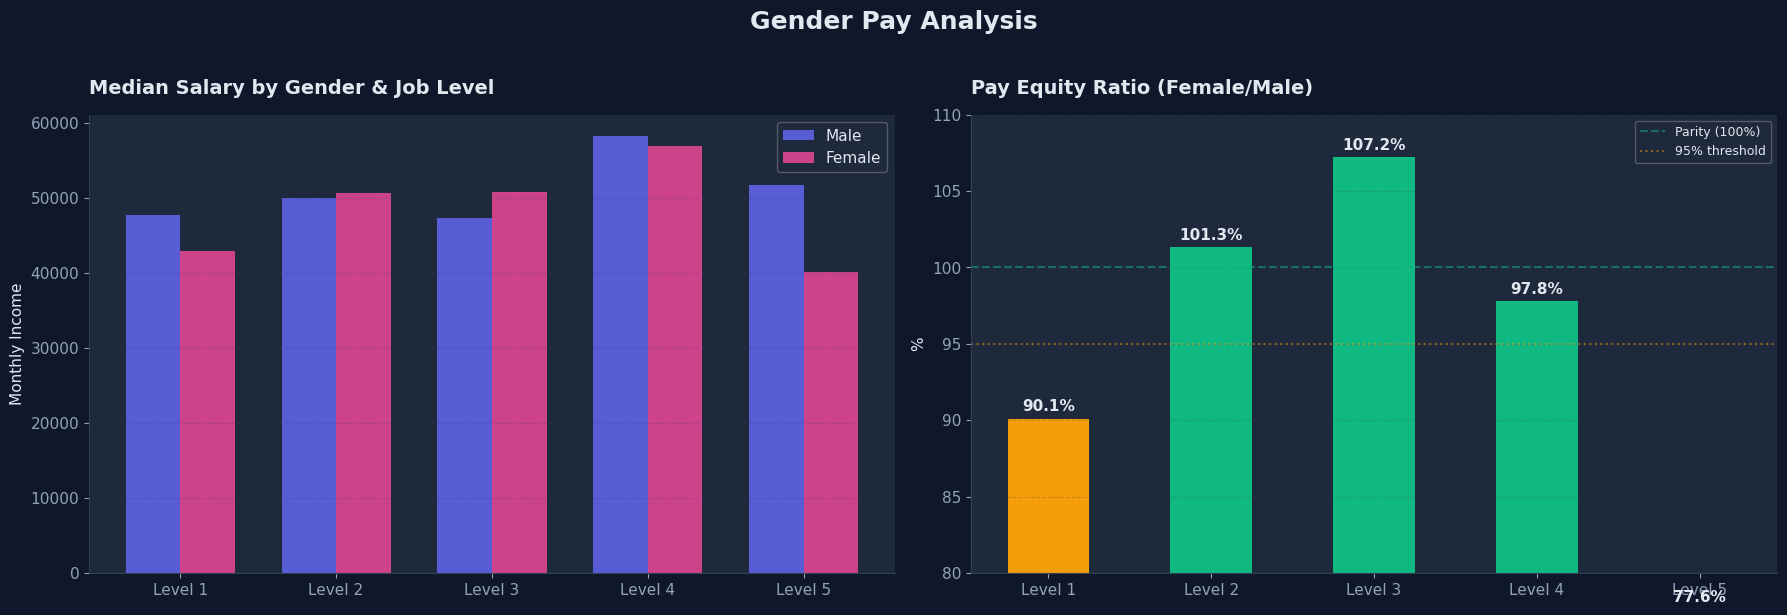

In [9]:
# Gender pay gap analysis (controlled by job level)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Gender Pay Analysis', fontsize=18, fontweight='bold', y=1.02)

# ── Median salary by gender and level ──
ax = axes[0]
salary_by_gender = df.pivot_table(
    values='MonthlyIncome', index='JobLevel', columns='Gender', aggfunc='median'
)
x = np.arange(len(salary_by_gender))
width = 0.35
bars1 = ax.bar(x - width/2, salary_by_gender['Male'], width, color=COLORS['primary'], 
               label='Male', edgecolor='none', alpha=0.85)
bars2 = ax.bar(x + width/2, salary_by_gender['Female'], width, color=COLORS['accent'], 
               label='Female', edgecolor='none', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Level {l}' for l in salary_by_gender.index])
format_ax(ax, 'Median Salary by Gender & Job Level', '', 'Monthly Income')
ax.legend(framealpha=0.3)

# ── Pay gap ratio (female/male) ──
ax = axes[1]
pay_ratio = (salary_by_gender['Female'] / salary_by_gender['Male'] * 100).round(1)
colors = [COLORS['success'] if r >= 95 else COLORS['warning'] if r >= 90 else COLORS['danger'] for r in pay_ratio]
bars = ax.bar([f'Level {l}' for l in pay_ratio.index], pay_ratio.values, color=colors, edgecolor='none', width=0.5)
ax.axhline(100, color=COLORS['success'], linestyle='--', alpha=0.5, label='Parity (100%)')
ax.axhline(95, color=COLORS['warning'], linestyle=':', alpha=0.5, label='95% threshold')
for bar, val in zip(bars, pay_ratio.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%', ha='center', fontsize=11, 
            fontweight='bold', color=COLORS['text'])
ax.set_ylim(80, 110)
format_ax(ax, 'Pay Equity Ratio (Female/Male)', '', '%')
ax.legend(framealpha=0.3, fontsize=9)

plt.tight_layout()
plt.savefig('../reports/gender_pay.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

---
## 6. Employee Satisfaction & Engagement

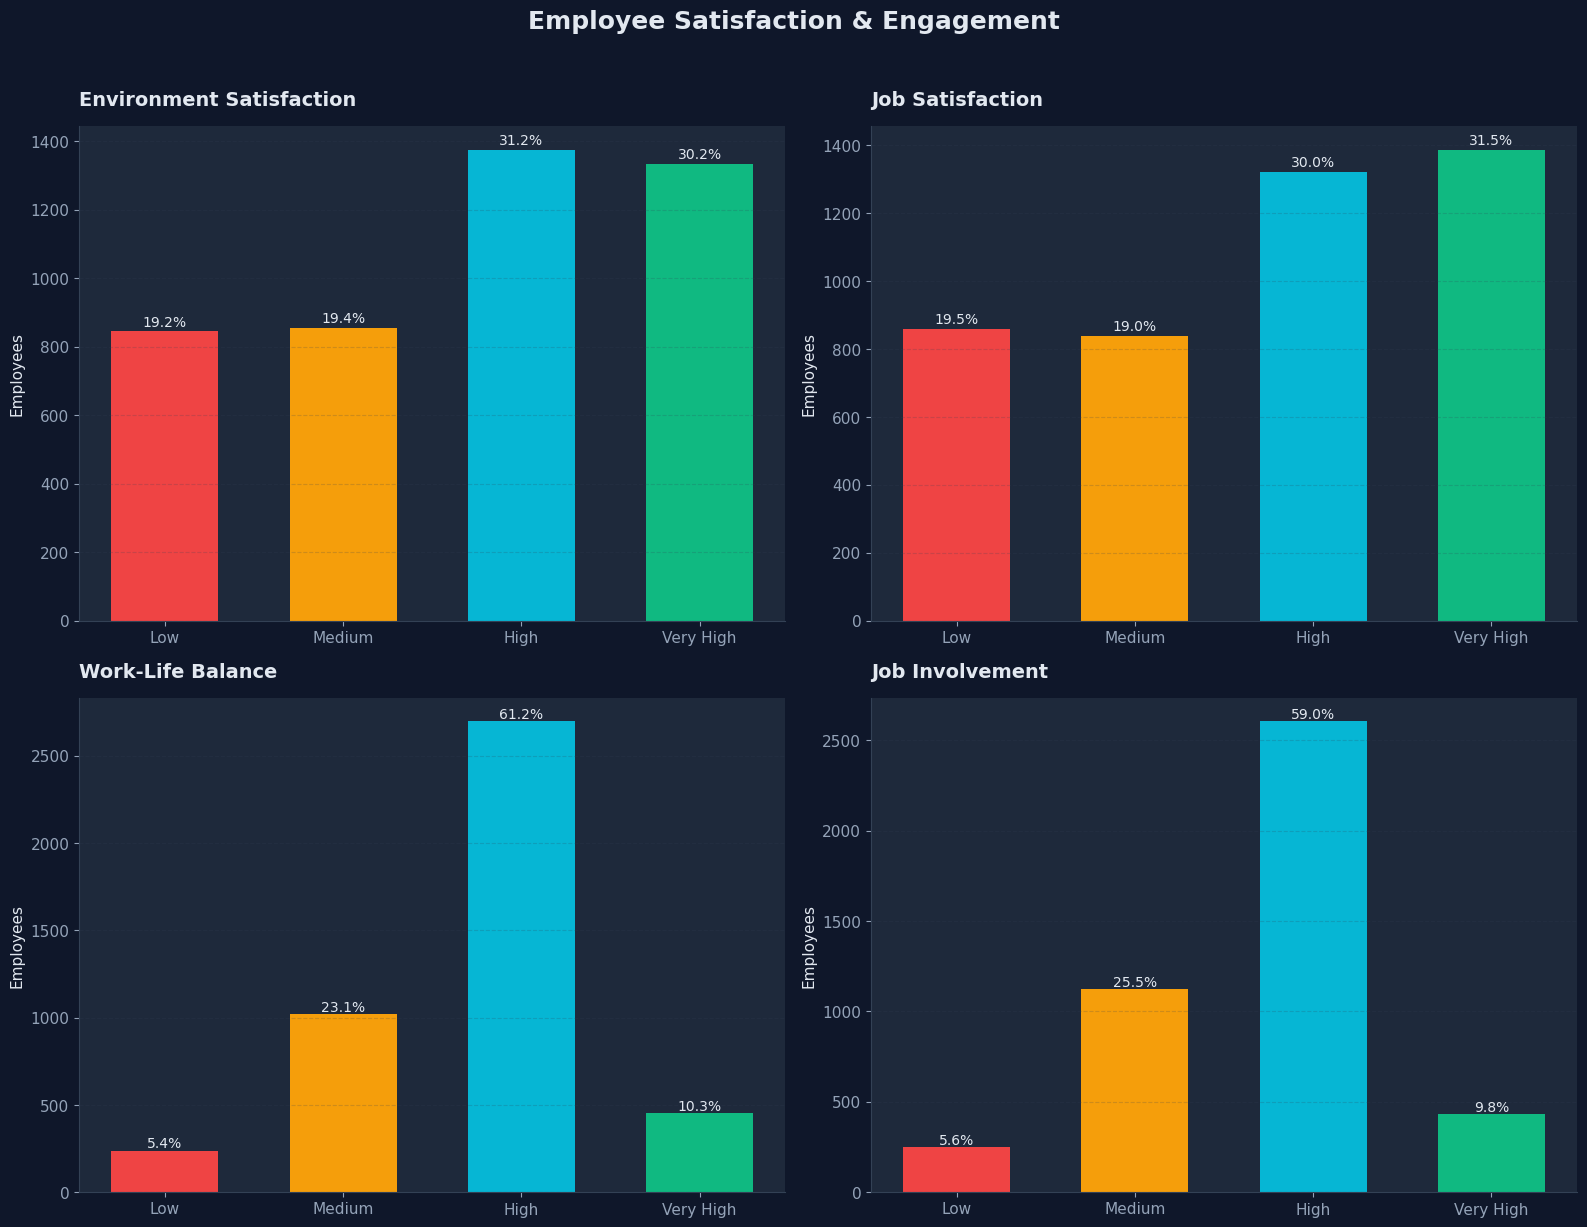

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Employee Satisfaction & Engagement', fontsize=18, fontweight='bold', y=1.02)

satisfaction_metrics = {
    'EnvironmentSatisfaction': 'Environment Satisfaction',
    'JobSatisfaction': 'Job Satisfaction',
    'WorkLifeBalance': 'Work-Life Balance',
    'JobInvolvement': 'Job Involvement'
}

level_labels = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}
level_colors = [COLORS['danger'], COLORS['warning'], COLORS['info'], COLORS['success']]

for ax, (col, title) in zip(axes.flat, satisfaction_metrics.items()):
    counts = df[col].value_counts().sort_index()
    labels = [level_labels.get(k, str(k)) for k in counts.index]
    bars = ax.bar(labels, counts.values, color=level_colors[:len(counts)], edgecolor='none', width=0.6)
    for bar, val in zip(bars, counts.values):
        pct = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, val + 15, f'{pct:.1f}%', 
                ha='center', fontsize=10, color=COLORS['text'])
    format_ax(ax, title, '', 'Employees')

plt.tight_layout()
plt.savefig('../reports/satisfaction_engagement.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

---
## 7. Correlation Heatmap

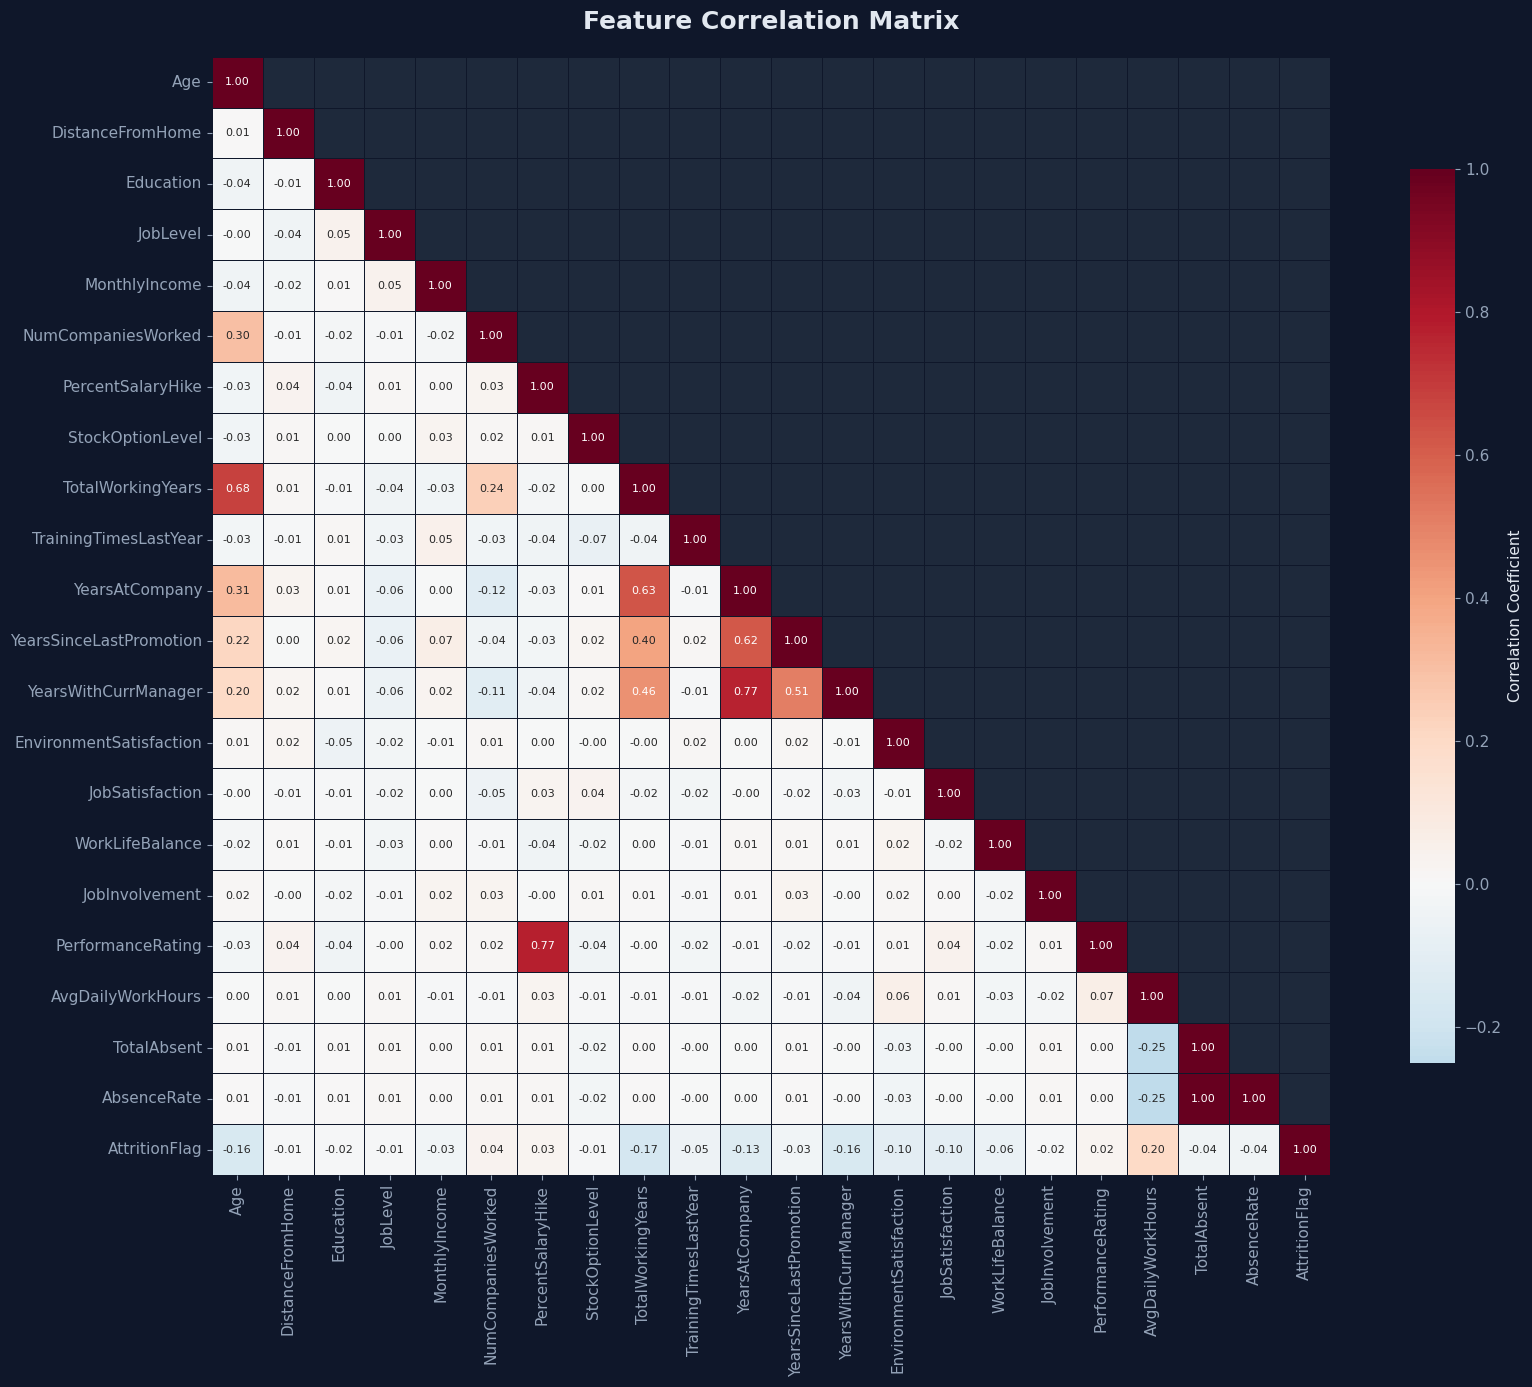


=== Top Correlations with Attrition ===
AvgDailyWorkHours          0.201688
TotalWorkingYears          0.170162
Age                        0.159205
YearsWithCurrManager       0.156199
YearsAtCompany             0.134392
JobSatisfaction            0.104017
EnvironmentSatisfaction    0.101625
WorkLifeBalance            0.062975
TrainingTimesLastYear      0.049431
AbsenceRate                0.043552


In [11]:
# Select numeric columns for correlation
numeric_cols = [
    'Age', 'DistanceFromHome', 'Education', 'JobLevel', 'MonthlyIncome',
    'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel',
    'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
    'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance',
    'JobInvolvement', 'PerformanceRating',
    'AvgDailyWorkHours', 'TotalAbsent', 'AbsenceRate',
    'AttritionFlag'
]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', center=0,
    cmap='RdBu_r', linewidths=0.5, linecolor=COLORS['bg'],
    square=True, ax=ax,
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)

ax.set_title('Feature Correlation Matrix', fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

# Top correlations with Attrition
print('\n=== Top Correlations with Attrition ===')
attrition_corr = corr_matrix['AttritionFlag'].drop('AttritionFlag').abs().sort_values(ascending=False)
print(attrition_corr.head(10).to_string())

---
## 8. Key Findings Summary

### Workforce Composition
- The workforce is predominantly in **R&D (65.4%)**, followed by Sales (30.3%) and HR (4.3%)
- **60/40 male/female split** with relatively balanced representation across levels
- Majority of employees hold a **Bachelor's degree (38.8%)**, primarily in Life Sciences and Medical fields

### Organizational Health Indicators
- Overall **attrition rate of 16.1%** — above the industry average, signaling a retention challenge
- Salary distribution shows expected exponential growth across job levels, with Level 5 (senior leadership) significantly above others
- **Promotion stagnation** is visible — a significant portion of employees have not been promoted in 5+ years

### Areas Requiring Deeper Investigation
- What drives the 16% attrition? → **Notebook 02: Turnover Deep Dive**
- Are attendance patterns linked to disengagement? → **Notebook 03: Engagement & Attendance**
- Can we predict who will leave next? → **Notebook 04: Predictive Model**